## Dust in SPT from 353GHz and 100GHz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import healpy as hp
import xpol
import os 

os.environ['KMP_DUPLICATE_LIB_OK']='True'


In [2]:
nside = 2048

lmax = 3000

ell = np.arange(lmax)

fact = ell*(ell+1)/2/np.pi




### Maps PR2 PR4

In [3]:
# Planck2

#m353n=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_N.fits")
#m353=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_full.fits")

#m100=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_100_2048_R2.00_full.fits")
#m100n=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_100_2048_R2.00_N.fits")
#m353_1=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_halfmission-1.fits")
#m353_2=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_353_2048_R2.00_halfmission-2.fits")
#m857_1=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_857_2048_R2.00_halfmission-1.fits")
#m857_2=hp.read_map("/Users/mdouspis/DATA/PLANCK2/HFI_SkyMap_857_2048_R2.00_halfmission-2.fits")


##PR4 dipole

dipole = hp.read_map("/Users/mdouspis/DATA/PLANCK4/dipole_nside2048.fits")

# Planck4 check other half

#353
#m353_1=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_353_2048_R4.00_full-ringhalf-1.fits")
#m353_2=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_353_2048_R4.00_full-ringhalf-2.fits")
#m353_1-=dipole
#m353_2-=dipole
#545
m545_1=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_545_2048_R4.00_full-ringhalf-1.fits")
m545_2=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_545_2048_R4.00_full-ringhalf-2.fits")
m545_1-=dipole
m545_2-=dipole


### detector sets

m353_1=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_353-ds3_2048_R4.00_full.fits")
m353_2=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_353-ds4_2048_R4.00_full.fits")
m353_1-=dipole
m353_2-=dipole

m857_1=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_857-ds3_2048_R4.00_full.fits")
m857_2=hp.read_map("/Users/mdouspis/DATA/PLANCK4/HFI_SkyMap_857-ds4_2048_R4.00_full.fits")
m857_1-=dipole
m857_2-=dipole



#m353_1 = np.vstack([m353_1,m353_1*0,m353_1*0 ])
#m353_2 = np.vstack([m353_2,m353_2*0,m353_2*0 ])
#m545_1 = np.vstack([m545_1,m545_1*0,m545_1*0 ])
#m545_2 = np.vstack([m545_2,m545_2*0,m545_2*0 ])

print(np.shape(m353_1))
print(np.shape(m545_1))
print(np.shape(m857_1))


(50331648,)
(50331648,)
(50331648,)


### Beams

In [4]:
#PR4

rimo=fits.getdata("/Users/mdouspis/DATA/PLANCK4/HFI_RIMO_R4.00.fits",2)

bl_857 = hp.gauss_beam(fwhm=rimo["FWHM"][5]/60.*np.pi/180.,lmax=lmax-1)
bl_545 = hp.gauss_beam(fwhm=rimo["FWHM"][4]/60.*np.pi/180.,lmax=lmax-1)
bl_353 = hp.gauss_beam(fwhm=rimo["FWHM"][3]/60.*np.pi/180.,lmax=lmax-1)
bl_100 = hp.gauss_beam(fwhm=rimo["FWHM"][0]/60.*np.pi/180.,lmax=lmax-1)

fwhm_rad = rimo["FWHM"][:]/60.*np.pi/180.

print(rimo["FWHM"][:])

[9.88 7.18 4.87 4.65 4.72 4.39]


### MASKS



In [5]:
# mask PS

maskps = hp.read_map("/Users/mdouspis/SCIENCES/AMAS/ISSI/mask_apriori_80_MC_PS3s_CO15_PCC_apod_allinone.fits")

mask_p = hp.read_map("/Users/mdouspis/DATA/PLANCK2/mask_dust_fsky_0.85.fits.gz")


mask_p = xpol.apodization(mask_p*maskps,1)
mask_p[mask_p==1e-5]=0.

fsky_p=np.sum(mask_p)/np.size(mask_p)

print("fsky Planck=", fsky_p)


fsky Planck= 0.7882092733310686


In [6]:

#spt=hp.read_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_Planck_min_variance_ymap_2048_partial.fits", verbose=False)
#mask = spt*0
#mask[spt >0 ] =1
#r = hp.Rotator(coord=['E','G'])
#maskg=r.rotate_map_pixel(mask)

#hp.write_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_ingal_2048.fits", maskg)



maskg = hp.read_map("/Users/mdouspis/SCIENCES/GALCLUSTER/MAGYC_CODES/Data/mask_SPTSZ_ingal_2048.fits")

maskg = xpol.apodization( maskg*maskps, 1.)
maskg[maskg==1e-5]=0.

fsky_spt=np.sum(maskg)/np.size(maskg)

print("fsky SPT=", fsky_spt)



fsky SPT= 0.05112659320060201


0.0
0.0


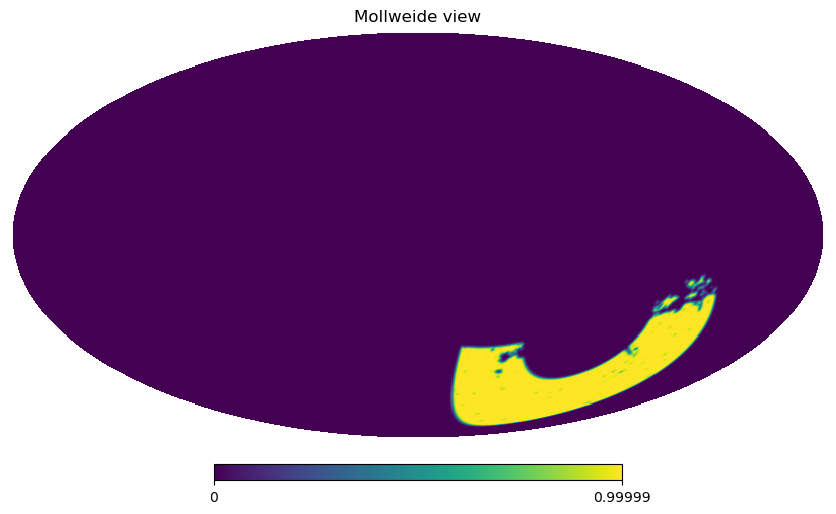

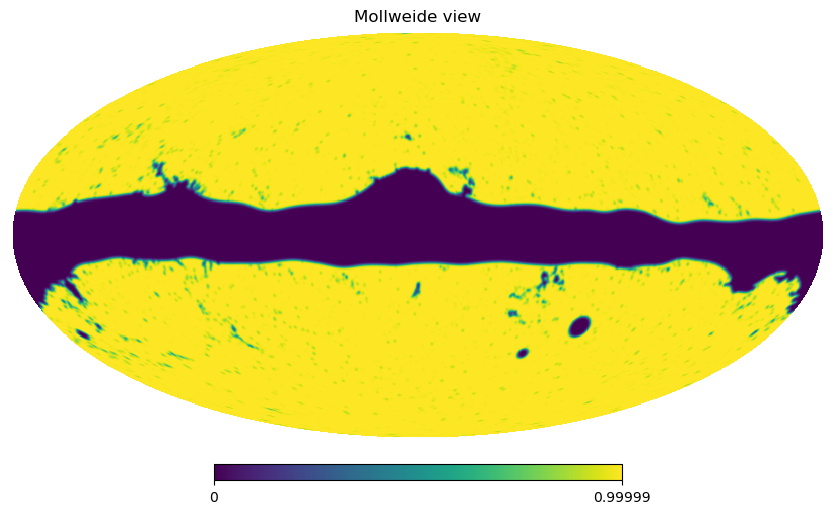

In [7]:
hp.mollview(maskg)
hp.mollview(mask_p)

print(np.min(maskg))
print(np.min(mask_p))



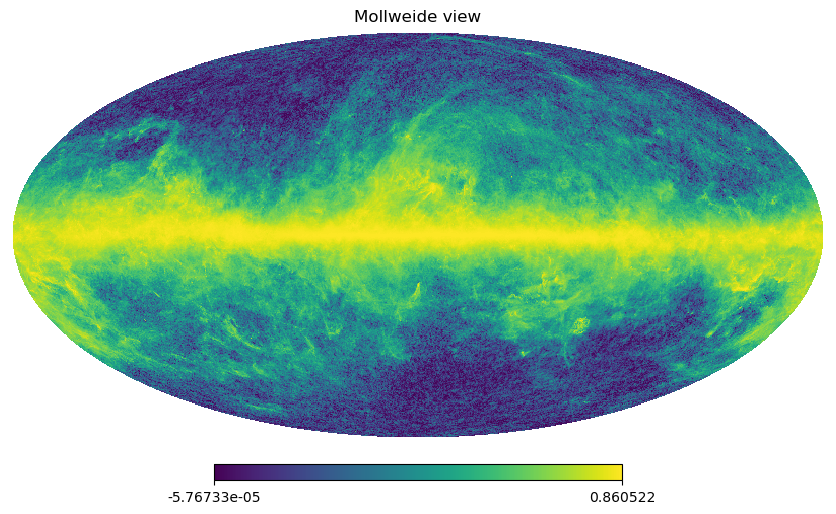

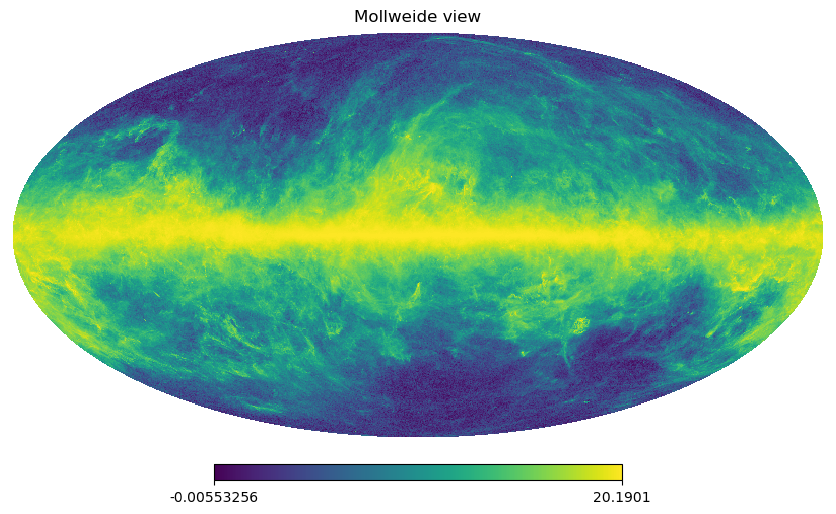

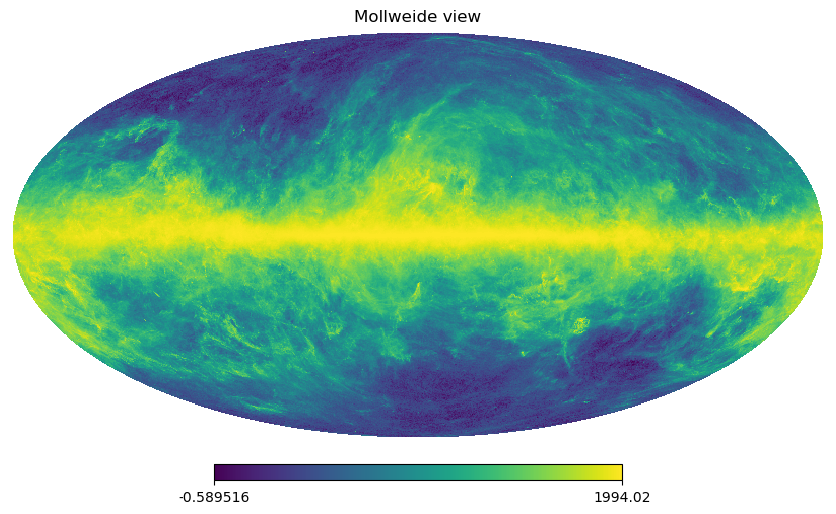

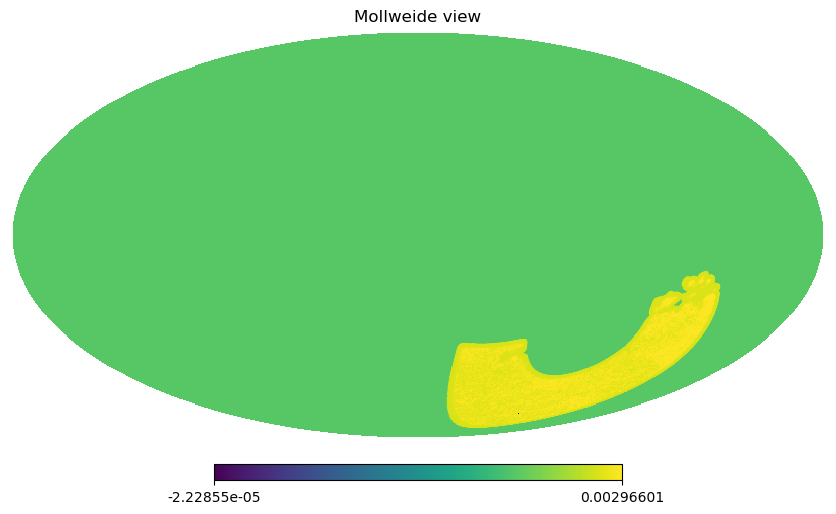

In [8]:


hp.mollview(m353_1, norm="hist")
hp.mollview(m545_1, norm="hist")
hp.mollview(m857_1, norm="hist")

hp.mollview(maskg*m353_1, norm="hist")




## CMB spectrum

In [9]:
file="COM_PowerSpect_CMB-base-plikHM-TT-lowTEB-minimum-theory_R2.02.txt"
cmbtemp = np.genfromtxt("/Users/mdouspis/DATA/PLANCK2/"+file)

print(np.shape(cmbtemp), lmax)
cmb=np.zeros(lmax)
ll=cmbtemp[:,0].astype("int")
cmb[ll[ll<np.max(ll)]]=cmbtemp[ll<np.max(ll),1]


(2507, 6) 3000


## SZ spectrum 

In [10]:
tr = fits.getdata("/Users/mdouspis/SCIENCES/HillikWork/modules/data/foregrounds/tkSZ_Dl_SZDB.fits")
md_ell, sztemp = tr["ell"], tr["tSZ_Dl_mod_95x150_muK2"]

Atsz = 3.5
tszat353_143_carre = 4.64
tszat100_143_carre = 2.10

sz353 = (sztemp/sztemp[3000]*Atsz*tszat353_143_carre)[0:lmax] 
sz100 = (sztemp/sztemp[3000]*Atsz*tszat100_143_carre)[0:lmax] 


### CIB

(31, 13)
1.9486139800454303e-11
[  33.5   97.5  161.5  225.5  289.5  353.5  417.5  481.5  545.5  609.5
  673.5  737.5  801.5  865.5  929.5  993.5 1057.5 1121.5 1185.5 1249.5
 1313.5 1377.5 1441.5 1505.5 1569.5 1633.5 1697.5 1761.5 1825.5 1889.5
 1953.5]


/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/3922651961.py:58: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(000,3000)


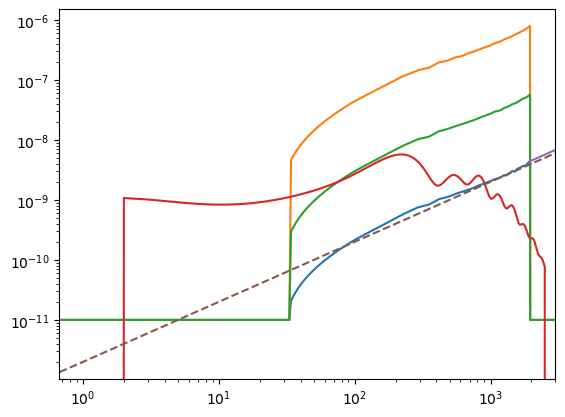

In [11]:

# CIB
cib = np.genfromtxt("/Users/mdouspis/SCIENCES/HillikWork/software/hillik/data/cib_extra_13500.dat")

lcib = cib[:,0]
dlcib = cib[:,1]



cib21 = np.genfromtxt("/Users/mdouspis/DATA/PLANCK4/Cl_CIB_T1T2.csv", delimiter=",", skip_header=6)

print(np.shape(cib21))

ellcib = cib21[:,0]

factcib = ellcib*(ellcib+1)/2./np.pi




cib_353_545o = cib21[:,1]/(58.04*287.450)*1e-12*factcib
cib_353_857o = cib21[:,2]/(2.27*287.450)*1e-12*factcib
cib_545_857o = cib21[:,3]/(58.04*2.27)*1e-12*factcib
cib_353_353o = cib21[:,4]/(287.450**2)*1e-12*factcib
cib_545_545o = cib21[:,5]/(58.04**2)*1e-12*factcib
cib_857_857o = cib21[:,6]/(2.27**2)*1e-12*factcib




from scipy import interpolate



f = interpolate.interp1d(ellcib, cib_353_353o, bounds_error=False, fill_value=1e-11)
cib_353_353 = f(ell)
f = interpolate.interp1d(ellcib, cib_545_545o, bounds_error=False, fill_value=1e-11)
cib_545_545 = f(ell)
f = interpolate.interp1d(ellcib, cib_353_545o, bounds_error=False, fill_value=1e-11)
cib_353_545 = f(ell)
f = interpolate.interp1d(ellcib, cib_857_857o, bounds_error=False, fill_value=1e-11)
cib_857_857 = f(ell)
f = interpolate.interp1d(ellcib, cib_353_857o, bounds_error=False, fill_value=1e-11)
cib_353_857 = f(ell)
f = interpolate.interp1d(ellcib, cib_545_857o, bounds_error=False, fill_value=1e-11)
cib_545_857 = f(ell)



plt.loglog(ell, cib_353_353)
plt.loglog(ell, cib_545_545)
plt.loglog(ell, cib_353_545)

plt.plot(ell, cmb*1e-12)

print(np.min(cib_353_353o))
print(ellcib)

plt.xlim(000,3000)
plt.plot([ellcib[-1], ellcib[-1]*2], [cib_353_353o[-1], (cib_353_353o[-1])*2**1.])
plt.plot(ell, 2e-9*(ell/1000)**1. , "--")

###  Maps Spectra anafast

In [12]:

#cl353  = hp.anafast(m353*maskg, lmax=lmax)
#cl353n = hp.anafast(m353n*maskg, lmax=lmax)

#cl353_pr4  = hp.anafast(m353_1*maskg)


#cl100  = hp.anafast(m100*maskg)
#cl100n = hp.anafast(m100n*maskg)



### Spectra from Xpol 

In [13]:

#lmins = np.logspace(np.log10(2),np.log10(3000),30)[2:29].astype("int")
#lmaxs = np.logspace(np.log10(2),np.log10(3000),30)[3:].astype("int")
#binning = xpol.Bins(lmins, lmaxs)


binning1 = xpol.Bins.fromdeltal(20, 200,10)
binning2 = xpol.Bins.fromdeltal(200, 1000,20)
binning3 = xpol.Bins.fromdeltal(1000, lmax,100)

lmins=np.hstack([binning1.lmins,binning2.lmins,binning3.lmins])
lmaxs=np.hstack([binning1.lmaxs,binning2.lmaxs,binning3.lmaxs])
binning = xpol.Bins(lmins, lmaxs)


lb = binning.lbin

print("nbins", np.shape(lb))

xp_spt = xpol.Xpol( maskg, bins=binning, polar=False)
xp_p = xpol.Xpol( mask_p, bins=binning, polar=False)

Dl = True


nbins (78,)


In [14]:
#binning.lbin


In [15]:
# 4 maps

#maps = [m353_1,m353_2,m545_1,m545_2]
#mapnames = ['m353_1','m353_2','m545_1','m545_2']
#fwhm = [4.818, 4.818, 4.675, 4.675]
#print(np.shape(maps))
#auto = xpol.listcross( [0,1,2,3], auto=True)
#nauto = len(auto)
#print(auto)

# 6 maps


maps = [m353_1,m353_2, m545_1, m545_2, m857_1, m857_2]
mapnames = ['m353_1','m353_2', 'm545_1', 'm545_2', 'm857_1', 'm857_2']
fwhm    = [fwhm_rad[3],fwhm_rad[3],fwhm_rad[4],fwhm_rad[4],fwhm_rad[5],fwhm_rad[5] ]
print(np.shape(maps))
cross = xpol.listcross(np.arange(np.size(mapnames)), auto=False)
ncross = len(cross)
print(cross)




(6, 50331648)
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]


In [16]:
allcross = True

In [17]:
if not allcross:

    pcl_spt, cl_spt_353 = xp_spt.get_spectra(m353_1, m353_2, Dl=Dl, bell1=bl_353, bell2=bl_353)
    pcl_spt, cl_spt_545 = xp_spt.get_spectra(m545_1, m545_2, Dl=Dl, bell1=bl_545, bell2=bl_545)

    pcl_spt, cl_spt_353_545 = xp_spt.get_spectra(m353_1, m545_2, Dl=Dl, bell1=bl_353, bell2=bl_545)
    pcl_spt, cl_spt_545_353 = xp_spt.get_spectra(m545_1, m353_2, Dl=Dl, bell1=bl_545, bell2=bl_353)
    
    pcl_spt, cl_spt_857_857 = xp_spt.get_spectra(m857_1, m857_2, Dl=Dl, bell1=bl_857, bell2=bl_857)




In [18]:
#np.shape(maps[2])


In [19]:
#print(np.shape(cl_spt_857_857))
#print(np.shape(cl_spt_353))

In [20]:
#planck mask

pcl_p, cl_p_353 = xp_p.get_spectra(m353_1, m353_2, Dl=Dl, bell1=bl_353, bell2=bl_353)


In [21]:


if allcross:
    cls = np.zeros( (6,6,binning.nbins) )
    for  m1,m2 in cross:
        print(m1,m2)
        bell1 = hp.gauss_beam( fwhm[m1], lmax=3*nside-1)
        bell2 = hp.gauss_beam( fwhm[m2], lmax=3*nside-1)
        pcl,cl = xp_spt.get_spectra( maps[m1], maps[m2], Dl=Dl, bell1=bell1, bell2=bell2)
        #print(cl.shape)
    
        cls[m1,m2] = cl#[ [0,1,2,3,4,5,6,7,8], :]
        #cls[m2,m1] = cl#[ [0,1,2,6,7,8,3,4,5], :]


0 1
0 2
0 3
0 4
0 5
1 2
1 3
1 4
1 5
2 3
2 4
2 5
3 4
3 5
4 5


### Dust models

In [22]:

ell2 = np.copy(ell)
ell2[0]=1e-10
               
mod1 = ((ell2)/100)**(-1.2)*1e-7

mod2 = fact*((ell2)/100)**(-2.4)*1e-12


mod3 = fact*((ell2)/100)**(-2.2)*1e-12




/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/1448212141.py:4: RuntimeWarning: divide by zero encountered in power
  mod1 = ((ell2)/100)**(-1.2)*1e-7
/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/1448212141.py:6: RuntimeWarning: divide by zero encountered in power
  mod2 = fact*((ell2)/100)**(-2.4)*1e-12
/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/1448212141.py:6: RuntimeWarning: invalid value encountered in multiply
  mod2 = fact*((ell2)/100)**(-2.4)*1e-12
/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/1448212141.py:9: RuntimeWarning: divide by zero encountered in power
  mod3 = fact*((ell2)/100)**(-2.2)*1e-12
/var/folders/tg/4xtyvf6d63n7y34nzq02jcjw0000gn/T/ipykernel_7796/1448212141.py:9: RuntimeWarning: invalid value encountered in multiply
  mod3 = fact*((ell2)/100)**(-2.2)*1e-12


In [23]:

if not allcross:
    print(np.shape(fact))
    print(np.shape(cl353))
    print(np.shape(bl_353))


    cl_spt_353_545[0][0]=np.nan
    cl_spt_545_353[0][0]=np.nan
    cl_spt_545[0][0]=np.nan
    cl_spt_353[0][0]=np.nan

    #print(binning.bin_spectra(cib_353_353, Dl=False))


### Plotting

In [24]:

#print(cl_spt_353[0][10]/cl_spt_857_857[10])

## remove CIB and CMB

0 1
1.0
0 2
0.06237696134491007
0 3
0.06308165319402634
0 4
0.0008977576533005763
0 5
0.0008873491542579189
1 2
0.061336211304464275
1 3
0.06204434171616792
1 4
0.0008833164518840948
1 5
0.000873272252312853
2 3
0.0037703305581698173
2 4
5.346932937537428e-05
2 5
5.286403853244495e-05
3 4
5.4019500167549446e-05
3 5
5.340354962486491e-05
4 5
7.488253399149678e-07


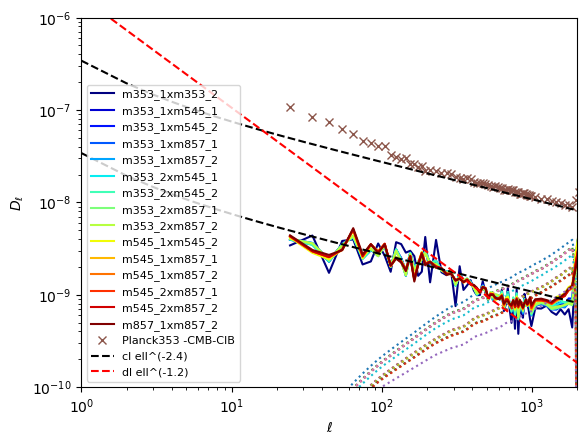

In [25]:
colors = plt.cm.jet(np.linspace(0, 1, 15))

if not allcross:
    
    plt.figure()
    #plt.loglog(ell, (fact*(cl353-cl353n)[:lmax])/bl_353**2/fsky_spt - cmb[:lmax]*1e-12, label="anafast SPT 353-N-CMB-SZ bl corr")

    plt.loglog(lb,  cl_spt_353[0]-binning.bin_spectra(cib_353_353, Dl=False)-0e-9*(lb/3000)**2 - binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(sz353, Dl=False)*1e-12, label="xpol 1x2 SPT353 - CMB - CIB")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")
    plt.loglog(lb,  (cl_spt_545[0]-binning.bin_spectra(cib_545_545, Dl=False)-0*1.4e-6*(lb/3000)**2  - binning.bin_spectra(cmb, Dl=False)*1e-12)/200., label="xpol 1x2 SPT545 - CMB -CIB (div by 200)")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")
    plt.loglog(lb,  (cl_spt_353_545[0]- binning.bin_spectra(cib_353_545, Dl=False) - binning.bin_spectra(cmb, Dl=False)*1e-12)/np.sqrt(200.), label="xpol 1x2 SPT353x545 - CMB -CIB (div by sqrt(200))")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")
    plt.loglog(lb,  (cl_spt_545_353[0]- binning.bin_spectra(cib_353_545, Dl=False) - binning.bin_spectra(cmb, Dl=False)*1e-12)/np.sqrt(200.), label="xpol 1x2 SPT545x353 - CMB -CIB (div by sqrt(200))")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")
    plt.loglog(lb,  (cl_spt_857_857- binning.bin_spectra(cib_857_857, Dl=False) - binning.bin_spectra(cmb, Dl=False)*1e-12)*1.3e-7, label="xpol 1x2 SPT857x857 - CMB -CIB (div by sqrt(200))")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")

    plt.loglog(lb,  cl_p_353[0]-binning.bin_spectra(cib_353_353, Dl=False)- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(sz353, Dl=False)*1e-12, "x", label="xpol 1x2 Planck353 -CMB-CIB")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")


    #plt.plot(ell, mod1/20, label="dl ell^(-1.2)")
    plt.plot(ell, mod2*1.5,":", label="cl ell^(-2.4)")
    plt.plot(ell, mod2*18, "--", label="cl ell^(-2.4)")

    #plt.plot(ell, mod3*2., "-.", label="cl ell^(-2.)")



    plt.xlim(20,1900)
    plt.ylim(1e-11,1e-7)
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$D_{\ell}$')


    
    
    plt.plot(ll, cmbtemp[:,1]*1e-12, ":")
    plt.plot(md_ell[:3000], sz353*1e-12, label="sz353")
    #plt.plot(ell, cib_353_353,label="CIB")
    #plt.plot(ell, cib_545_545/200., "--")

    plt.legend(fontsize=8)

    #print(cl_spt_353[0,:])

    #plt.plot(lcib,dlcib*2.5e-9)

if allcross:

    cib = [cib_353_353, cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_545_545,cib_545_857,cib_545_857,
           cib_545_857,cib_545_857,
           cib_857_857,]
    
    for  j, (m1,m2) in enumerate(cross[0:15]):
        print(m1,m2)
        truc0= cls[0,1]- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(cib[0], Dl=False)
        truc = cls[m1,m2]- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(cib[j], Dl=False)
        coeff = np.median(truc0[lb<200][4:]/truc[lb<200][4:])
        print(coeff)
        #plt.plot(lb, (cls[0,0,0,:]+cls[1,1,0,:])/2.- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(sz353, Dl=False)*1e-12, "--",label =" auto 1x1 SPT -CMB-SZ")

        plt.loglog(lb, (truc)*coeff, color=colors[j],label=mapnames[m1]+"x"+mapnames[m2])#)#, label = "cross"+ mapnames[m1]+"x"+mapnames[m2]+"  SPT -CMB")
        
        plt.plot(lb,binning.bin_spectra(cib[j], Dl=False)*coeff, ":")
        
    plt.loglog(lb,  cl_p_353-binning.bin_spectra(cib[0], Dl=False)- binning.bin_spectra(cmb, Dl=False)*1e-12, "x", label="Planck353 -CMB-CIB")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")

    
    plt.plot(ell, mod2*1.7,"k--", label="cl ell^(-2.4)")
    plt.plot(ell, mod2*17,"k--")
    plt.plot(ell, mod1/15, "r--",label="dl ell^(-1.2)")
    #plt.plot(lb, (3e-9)*(lb/100.)**(-0.5), "--")
    plt.legend(fontsize=8)
    plt.xlim(1,2000)
    plt.ylim(1e-10,1e-6)
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$D_{\ell}$')

    

## removing CIB and l^2 and CMB

0 1
1.0
0 2
0.06237696134491007
0 3
0.06308165319402634
0 4
0.0008977576533005763
0 5
0.0008873491542579189
1 2
0.061336211304464275
1 3
0.06204434171616792
1 4
0.0008833164518840948
1 5
0.000873272252312853
2 3
0.0037703305581698173
2 4
5.346932937537428e-05
2 5
5.286403853244495e-05
3 4
5.4019500167549446e-05
3 5
5.340354962486491e-05
4 5
7.488253399149678e-07


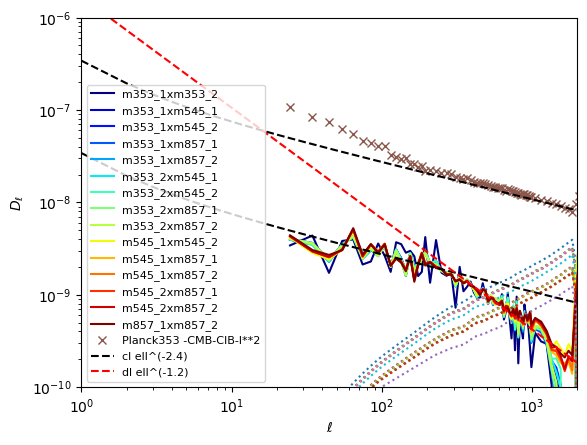

In [26]:
## removing a l**2 component


if allcross:

    cib = [cib_353_353, cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_545_545,cib_545_857,cib_545_857,
           cib_545_857,cib_545_857,
           cib_857_857,]
    
    for  j, (m1,m2) in enumerate(cross[0:15]):
        print(m1,m2)
        truc0= cls[0,1]- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(cib[0], Dl=False)
        truc = cls[m1,m2]- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(cib[j], Dl=False)
        coeff = np.median(truc0[lb<200][4:]/truc[lb<200][4:])
        print(coeff)
        #plt.plot(lb, (cls[0,0,0,:]+cls[1,1,0,:])/2.- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(sz353, Dl=False)*1e-12, "--",label =" auto 1x1 SPT -CMB-SZ")

        plt.loglog(lb, (truc)*coeff-3e-10*(lb/1000)**2, color=colors[j],label=mapnames[m1]+"x"+mapnames[m2])#)#, label = "cross"+ mapnames[m1]+"x"+mapnames[m2]+"  SPT -CMB")
        
        plt.plot(lb,binning.bin_spectra(cib[j], Dl=False)*coeff, ":")
        
    plt.loglog(lb,  cl_p_353-binning.bin_spectra(cib[0], Dl=False)- binning.bin_spectra(cmb, Dl=False)*1e-12-3.e-10*(lb/1000)**2, "x", label="Planck353 -CMB-CIB-l**2")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")

    
    plt.plot(ell, mod2*1.7,"k--", label="cl ell^(-2.4)")
    plt.plot(ell, mod2*17,"k--")
    plt.plot(ell, mod1/15, "r--",label="dl ell^(-1.2)")
    #plt.plot(lb, (3e-9)*(lb/100.)**(-0.5), "--")
    plt.legend(fontsize=8)
    plt.xlim(1,2000)
    plt.ylim(1e-10,1e-6)
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$D_{\ell}$')

    

## Removing only l^2 and CMB

0 1
1.0
0 2
0.06280699272103904
0 3
0.06344875649279992
0 4
0.0009216558880397868
0 5
0.0009118069041429079
1 2
0.06181995137017725
1 3
0.062466603997593365
1 4
0.0009091417761767423
1 5
0.0008995804932369264
2 3
0.0038738061011390655
2 4
5.637217541786351e-05
2 5
5.577533158156422e-05
3 4
5.690753906617179e-05
3 5
5.6300948077176675e-05
4 5
8.007610462851405e-07


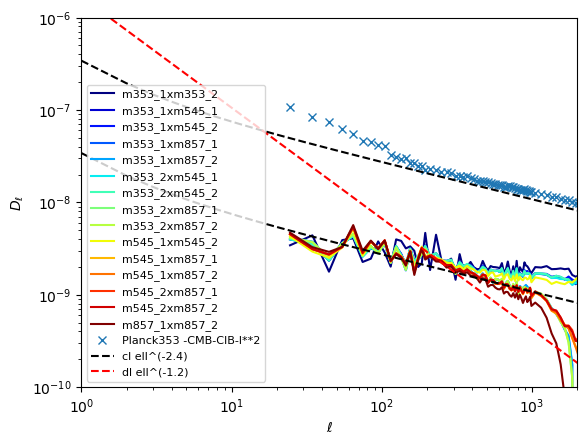

In [27]:
## removing only a l**2 component


if allcross:

    cib = [cib_353_353, cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_353_545,cib_353_545,cib_353_857,cib_353_857, 
           cib_545_545,cib_545_857,cib_545_857,
           cib_545_857,cib_545_857,
           cib_857_857,]
    
    for  j, (m1,m2) in enumerate(cross[0:15]):
        print(m1,m2)
        truc0= cls[0,1]- binning.bin_spectra(cmb, Dl=False)*1e-12#-binning.bin_spectra(cib[0], Dl=False)
        truc = cls[m1,m2]- binning.bin_spectra(cmb, Dl=False)*1e-12#-binning.bin_spectra(cib[j], Dl=False)
        coeff = np.median(truc0[lb<200][4:]/truc[lb<200][4:])
        print(coeff)
        #plt.plot(lb, (cls[0,0,0,:]+cls[1,1,0,:])/2.- binning.bin_spectra(cmb, Dl=False)*1e-12-binning.bin_spectra(sz353, Dl=False)*1e-12, "--",label =" auto 1x1 SPT -CMB-SZ")

        plt.loglog(lb, (truc)*coeff-8e-10*(lb/1000)**2, color=colors[j],label=mapnames[m1]+"x"+mapnames[m2])#)#, label = "cross"+ mapnames[m1]+"x"+mapnames[m2]+"  SPT -CMB")
        
        #plt.plot(lb,binning.bin_spectra(cib[j], Dl=False)*coeff, ":")
        
    plt.loglog(lb,  cl_p_353-0.0*binning.bin_spectra(cib[0], Dl=False)- binning.bin_spectra(cmb, Dl=False)*1e-12-8e-10*(lb/1000)**2, "x", label="Planck353 -CMB-CIB-l**2")# - binning.bin_spectra(cmb, Dl=True)*1e-12)#-binning.bin_spectra(sz353, Dl=True)*1e-12, label="x353-CMB-SZ bl corr")

    
    plt.plot(ell, mod2*1.7,"k--", label="cl ell^(-2.4)")
    plt.plot(ell, mod2*17,"k--")
    plt.plot(ell, mod1/15, "r--",label="dl ell^(-1.2)")
    #plt.plot(lb, (3e-9)*(lb/100.)**(-0.5), "--")
    plt.legend(fontsize=8)
    plt.xlim(1,2000)
    plt.ylim(1e-10,1e-6)
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$D_{\ell}$')

    

### mask 545

In [28]:
m545t = m545_1[0,:]

hp.mollview(m545t, norm="hist")

mask1 = np.zeros(np.size(m545t))+1

mask1[m545t< 0.1]=0.

hp.mollview(mask1)

mask2 = np.zeros(np.size(m545t))+1

mask2[m545t<0.01]=0.

hp.mollview(mask2*(1-mask1))


mask3 = np.zeros(np.size(m545t))+1



hp.mollview(mask3*(1-mask1)*(1-mask2))





IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed